<a href="https://colab.research.google.com/github/seungah-lab/Intelligence-powered-epidemiology/blob/main/Week_4_%EA%B2%BD%EC%82%AC%ED%95%98%EA%B0%95%EB%B2%95_%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 이분형 결과 - 로지스틱 회귀 모델 적용해보기

##### Keras를 이용한 전립선암 고위험군 분류 모델

###### 1. 환경 준비

In [7]:
import pandas as pd
import numpy as np

##### 2. 데이터 준비

In [8]:
# 1. 데이터 로드
df = pd.read_csv("https://web.stanford.edu/~hastie/ElemStatLearn/datasets/prostate.data", sep='\t', index_col=0)

# 2. 데이터 구조 확인
print("--- Data Info ---")
print(df.head())

# 2.5 파생 변수 생성 (Feature Engineering)
# 조건: age > 70 이고 lbph > -1.38629436 인 경우 cancer_status = 1, 아니면 0
# lbph 수치 -1.386...은 실제 값으로 약 0.25에 해당함.

def define_cancer_status(row):
    if row['age'] > 70 and row['lbph'] > -1.38629436:
        return 1
    else:
        return 0

# 새로운 열 'cancer_status' 추가
df['cancer_status'] = df.apply(define_cancer_status, axis=1)

# 생성된 클래스의 분포 확인 (Class Imbalance 체크)
print("--- Class Distribution ---")
print(df['cancer_status'].value_counts())

print(df.head())

--- Data Info ---
     lcavol   lweight  age      lbph  svi       lcp  gleason  pgg45      lpsa  \
1 -0.579818  2.769459   50 -1.386294    0 -1.386294        6      0 -0.430783   
2 -0.994252  3.319626   58 -1.386294    0 -1.386294        6      0 -0.162519   
3 -0.510826  2.691243   74 -1.386294    0 -1.386294        7     20 -0.162519   
4 -1.203973  3.282789   58 -1.386294    0 -1.386294        6      0 -0.162519   
5  0.751416  3.432373   62 -1.386294    0 -1.386294        6      0  0.371564   

  train  
1     T  
2     T  
3     T  
4     T  
5     T  
--- Class Distribution ---
cancer_status
0    86
1    11
Name: count, dtype: int64
     lcavol   lweight  age      lbph  svi       lcp  gleason  pgg45      lpsa  \
1 -0.579818  2.769459   50 -1.386294    0 -1.386294        6      0 -0.430783   
2 -0.994252  3.319626   58 -1.386294    0 -1.386294        6      0 -0.162519   
3 -0.510826  2.691243   74 -1.386294    0 -1.386294        7     20 -0.162519   
4 -1.203973  3.282789   58 -

##### 3. 모델 실행

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# 2. 독립 변수(x)와 종속 변수(y) 설정
# lpsa를 기반으로 전립선암 유무를 예측합니다.
x = df['lpsa'].values
y = df['cancer_status'].values

# 3. Keras 로지스틱 회귀 모델 생성
model = Sequential()
# 단일 입력(lpsa)이므로 input_dim=1, 출력은 확률값(0~1)이므로 sigmoid 활성화 함수 사용
model.add(Dense(1, input_dim=1, activation='sigmoid'))

# 컴파일: 이진 분류를 위한 binary_crossentropy 설정
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# 4. 모델 학습
# x와 y를 모델에 맞게 학습시킵니다.
model.fit(x, y, epochs=500, verbose=0)

##### 4. 모델 시각화

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


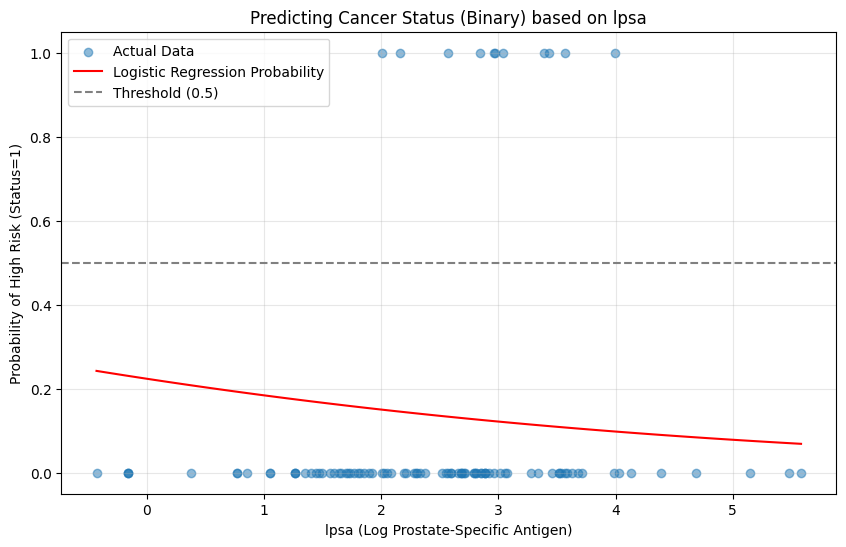

In [12]:
plt.figure(figsize=(10, 6))

# 실제 데이터 산점도 (x: lpsa, y: cancer_status)
plt.scatter(x, y, alpha=0.5, label='Actual Data')

# 모델의 예측 확률 곡선 시각화
# x축을 촘촘하게 나누어 부드러운 S-커브(Sigmoid)를 그립니다.
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_prob = model.predict(x_range)

plt.plot(x_range, y_prob, color='red', label='Logistic Regression Probability')
plt.axhline(0.5, color='gray', linestyle='--', label='Threshold (0.5)')
plt.title('Predicting Cancer Status (Binary) based on lpsa')
plt.xlabel('lpsa (Log Prostate-Specific Antigen)')
plt.ylabel('Probability of High Risk (Status=1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### 5. 특정 환자 데이터 기반 예측 (Inference)

In [14]:
test_lpsa = 3.0
prediction = model.predict(np.array([[test_lpsa]]))[0][0]
print(f"\nlpsa 수치가 {test_lpsa}일 경우, 전립선암을 갖고 있을 확률은 {prediction * 100:.2f}%입니다.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

lpsa 수치가 3.0일 경우, 전립선암을 갖고 있을 확률은 12.18%입니다.
